In [1]:
# Install required packages (run once per environment)

# Import all libraries
import pandas as pd                    # Data manipulation & analysis
import numpy as np                     # Numerical computing
import matplotlib.pyplot as plt        # Base plotting library
import seaborn as sns                  # Statistical visualizations
from scipy import stats                # Statistical tests (Pearson r)
import warnings
warnings.filterwarnings("ignore")      # Suppress minor warnings

# Configure plot defaults
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_style("whitegrid")
print("All libraries imported successfully")


All libraries imported successfully


In [3]:
# Load the Excel file
df = pd.read_excel(
    r'C:\Users\ankii\OneDrive\Desktop\Regional_Sales_Analysis\Data\Cleaned Data\Sales_Data_Cleaned.xlsx',
    sheet_name="Sales_Data_Cleaned",   # Specify sheet name explicitly
    parse_dates= ["order_date"],    # Auto-parse date column to datetime
)

print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")


Dataset loaded: 64,104 rows x 21 columns
Memory usage: 37.3 MB


In [4]:
df.head(3)

,order_number,order_date,customer_name,channel,product_name,quantity,unit_price,revenue,cost,state,...,us_region,lat,lon,budget,total_cost,profit,profit_margin_pct,order_month_name,order_month_num,order_month
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,...,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0,January,1,2014-01
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,...,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0,January,1,2014-01
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,...,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0,January,1,2014-01


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_number       64104 non-null  object        
 1   order_date         64104 non-null  datetime64[ns]
 2   customer_name      64104 non-null  object        
 3   channel            64104 non-null  object        
 4   product_name       64104 non-null  object        
 5   quantity           64104 non-null  int64         
 6   unit_price         64104 non-null  float64       
 7   revenue            64104 non-null  float64       
 8   cost               64104 non-null  float64       
 9   state              64104 non-null  object        
 10  state_name         64104 non-null  object        
 11  us_region          64104 non-null  object        
 12  lat                64104 non-null  float64       
 13  lon                64104 non-null  float64       
 14  budget

In [6]:
df[['quantity','unit_price','revenue','profit','profit_margin_pct']].describe().round(2)

,quantity,unit_price,revenue,profit,profit_margin_pct
count,64104.00,64104.00,64104.00,64104.00,64104.00
mean,8.44,2284.38,19280.68,7203.49,37.36
std,2.28,1663.60,15429.60,6626.12,13.24
min,5.00,167.50,837.50,125.62,15.00
25%,6.00,1031.80,8019.90,2542.55,26.00
50%,8.00,1855.90,14023.10,5091.46,37.00
75%,10.00,3606.28,27416.40,9922.16,49.00
max,12.00,6566.00,78711.60,45559.46,60.00


In [7]:
# Count missing values per column
missing = df.isnull().sum()
pct = (missing / len(df) * 100).round(2)

print(pd.DataFrame({"Count":missing,"Pct%":pct})[missing > 0])
print(f"\nTotal null cells: {missing.sum():,}")


        Count   Pct%
budget  48841  76.19

Total null cells: 48,841


In [8]:
# Check 1: Fully duplicate rows
full_dups = df.duplicated().sum()

# Check 2: Apparent order_number duplicates (expected - 6 lines/order)
unique_orders = df["order_number"].nunique()
lines_per_order = round(len(df) / unique_orders, 1)

print(f"Fully duplicate rows:     {full_dups}")
print(f"Unique order numbers:     {unique_orders:,}")
print(f"Avg lines per order:      {lines_per_order}")


Fully duplicate rows:     0
Unique order numbers:     10,684
Avg lines per order:      6.0


In [9]:
# Check all column types
for col in df.columns:
    print(f"  {col:<22} {str(df[col].dtype):<18}")


  order_number           object            
  order_date             datetime64[ns]    
  customer_name          object            
  channel                object            
  product_name           object            
  quantity               int64             
  unit_price             float64           
  revenue                float64           
  cost                   float64           
  state                  object            
  state_name             object            
  us_region              object            
  lat                    float64           
  lon                    float64           
  budget                 float64           
  total_cost             float64           
  profit                 float64           
  profit_margin_pct      float64           
  order_month_name       object            
  order_month_num        int64             
  order_month            object            


In [10]:
# Validate numeric ranges
checks = {
    "quantity":          {"min":5,  "max":12, "no_negatives":True},
    "unit_price":        {"min":0,  "max":None,"no_negatives":True},
    "revenue":           {"min":0,  "max":None,"no_negatives":True},
    "profit":            {"min":0,  "max":None,"no_negatives":True},
}
for col, rules in checks.items():
    neg = (df[col] < 0).sum()
    zero = (df[col] == 0).sum()
    print(f"{col}: min={df[col].min():.1f}, max={df[col].max():.1f},",
          f"negatives={neg}, zeros={zero}")


quantity: min=5.0, max=12.0, negatives=0, zeros=0
unit_price: min=167.5, max=6566.0, negatives=0, zeros=0
revenue: min=837.5, max=78711.6, negatives=0, zeros=0
profit: min=125.6, max=45559.5, negatives=0, zeros=0


In [11]:
# Rule 1: revenue must equal quantity × unit_price
rev_err = (abs(df["quantity"]*df["unit_price"] - df["revenue"]) > 0.01).sum()

# Rule 2: profit must equal revenue - total_cost
profit_err = (abs(df["revenue"]-df["total_cost"] - df["profit"]) > 0.01).sum()

# Rule 3: total_cost must equal cost × quantity
tc_err = (abs(df["cost"]*df["quantity"] - df["total_cost"]) > 0.01).sum()

# Rule 4: order_month_num must match order_date month
date_err = (df["order_date"].dt.month != df["order_month_num"]).sum()

print(f"Revenue = qty × price:        {rev_err} errors")
print(f"Profit = rev - total_cost:    {profit_err} errors")
print(f"Total_cost = cost × qty:      {tc_err} errors")
print(f"Month_num vs order_date:      {date_err} errors")


Revenue = qty × price:        0 errors
Profit = rev - total_cost:    0 errors
Total_cost = cost × qty:      0 errors
Month_num vs order_date:      0 errors


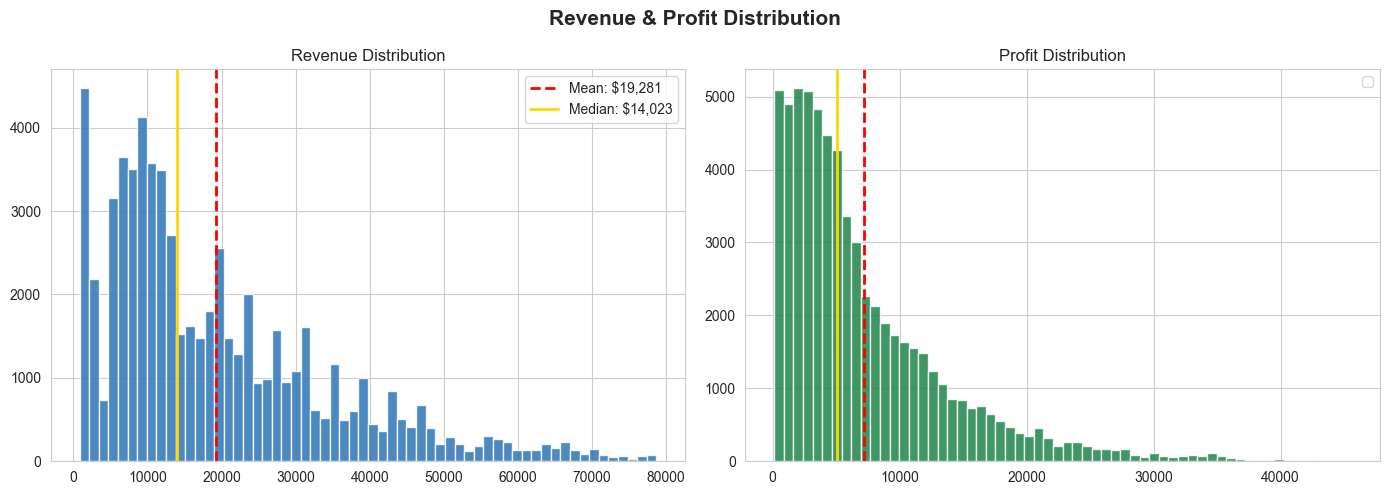

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Revenue & Profit Distribution", fontsize=15, fontweight="bold")

# Revenue Histogram
axes[0].hist(df["revenue"], bins=60, color="#2E75B6", alpha=0.85, edgecolor="white")
axes[0].axvline(df["revenue"].mean(), color="red", lw=2, ls="--",
    label=f'Mean: ${df["revenue"].mean():,.0f}')
axes[0].axvline(df["revenue"].median(), color="gold", lw=2,
    label=f'Median: ${df["revenue"].median():,.0f}')
axes[0].set_title("Revenue Distribution"); axes[0].legend()

# Profit Histogram
axes[1].hist(df["profit"], bins=60, color="#1E8449", alpha=0.85, edgecolor="white")
axes[1].axvline(df["profit"].mean(), color="red", lw=2, ls="--")
axes[1].axvline(df["profit"].median(), color="gold", lw=2)
axes[1].set_title("Profit Distribution"); axes[1].legend()
plt.tight_layout(); plt.savefig("chart1_distribution.png", dpi=150)


             Revenue  Profit  Avg_Margin
channel                                 
Distributor   387.14  145.77       37.56
Export        180.63   68.65       37.93
Wholesale     668.20  247.35       37.09
us_region
West         372.142308
South        335.135012
Midwest      320.322364
Northeast    208.369216
Name: revenue, dtype: float64


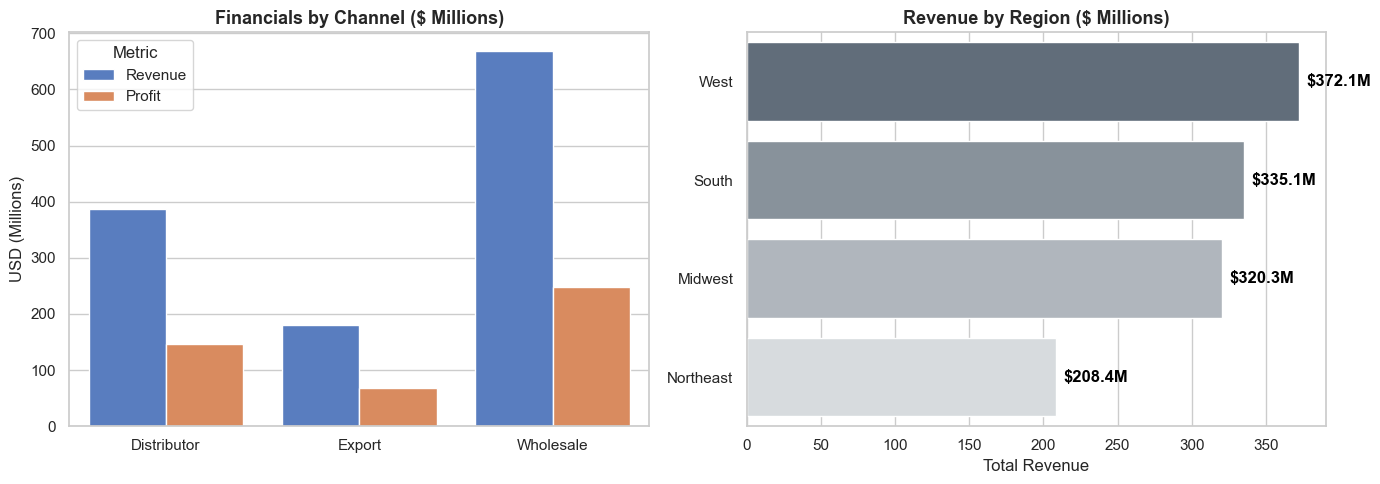

In [28]:
# Channel aggregation
channel_stats = df.groupby("channel").agg(
    Revenue=("revenue","sum"),
    Profit=("profit","sum"),
    Avg_Margin=("profit_margin_pct","mean")
).div({"Revenue":1e6,"Profit":1e6,"Avg_Margin":1}).round(2)
print(channel_stats)

# Region share
region_rev = df.groupby("us_region")["revenue"].sum().div(1e6).sort_values(ascending=False)
print(region_rev)


# --- 1. DATA PREPARATION ---
# Resetting index so Seaborn can access the columns
channel_plot_data = channel_stats.reset_index()
region_plot_data = region_rev.reset_index()
region_plot_data.columns = ['us_region', 'revenue']

# --- 2. COLOR CONSISTENCY MAPS ---
# We define specific colors for each category once
channel_colors = {"Distributor": "#3498db", "Export": "#e74c3c", "Wholesale": "#2ecc71"}
region_colors = {"West": "#5D6D7E", "South": "#85929E", "Midwest": "#AEB6BF", "Northeast": "#D6DBDF"}

# --- 3. CREATE THE DASHBOARD ---
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5)) # Compact size

# LEFT CHART: Multi-Metric Channel Analysis (Revenue & Profit)
# We melt the data to show Revenue and Profit side-by-side
melted_channels = channel_plot_data.melt(id_vars="channel", value_vars=["Revenue", "Profit"])

sns.barplot(data=melted_channels, x="channel", y="value", hue="variable", 
            palette="muted", ax=ax1)

ax1.set_title("Financials by Channel ($ Millions)", fontsize=13, fontweight='bold')
ax1.set_ylabel("USD (Millions)")
ax1.set_xlabel("")
ax1.legend(title="Metric")

# RIGHT CHART: Regional Revenue Share
# Using horizontal bars makes the region names easier to read
sns.barplot(data=region_plot_data, x="revenue", y="us_region", 
            palette=region_colors, ax=ax2)

ax2.set_title("Revenue by Region ($ Millions)", fontsize=13, fontweight='bold')
ax2.set_xlabel("Total Revenue")
ax2.set_ylabel("")

# Adding value labels to the ends of the horizontal bars
for i, v in enumerate(region_plot_data['revenue']):
    ax2.text(v + 5, i, f'${v:.1f}M', color='black', va='center', fontweight='bold')

# --- 4. FINISHING ---
plt.tight_layout()
plt.show()


year
2014    297.520729
2015    298.410710
2016    298.083670
2017    293.823837
Name: revenue, dtype: float64


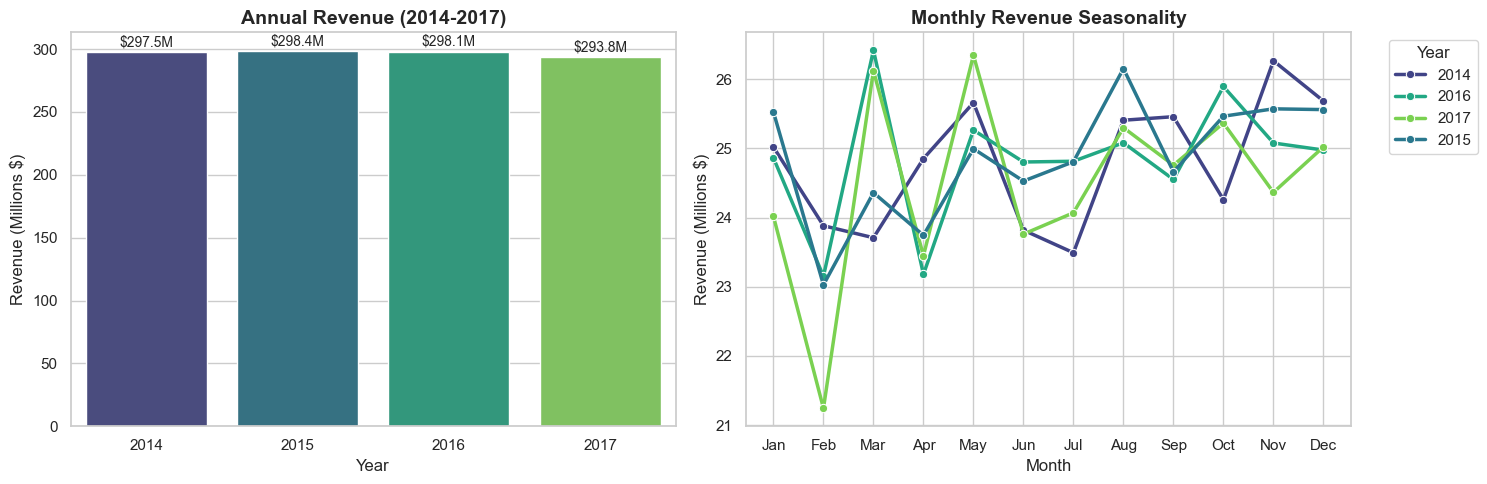

In [33]:
df["year"]  = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month

# Annual revenue (2014-2017 full years only)
yearly = df[df["year"] < 2018].groupby("year")["revenue"].sum().div(1e6)
print(yearly)

# Monthly breakdown by year for seasonality
monthly = df.groupby(["year","month"])["revenue"].sum().div(1e6).reset_index()




# --- 1. DATA PREP & FIXING THE TYPE MISMATCH ---
sns.set_theme(style="whitegrid")

# Convert years to strings to match the data index/columns
years = ["2014", "2015", "2016", "2017"]
colors = sns.color_palette("viridis", len(years))
# Dictionary keys are now strings: {'2014': color, ...}
year_palette = dict(zip(years, colors))

# Ensure the data matches the string type for the palette
yearly.index = yearly.index.astype(str)
monthly['year'] = monthly['year'].astype(str)

# Filter monthly data to match the string years
monthly_filtered = monthly[monthly["year"].isin(years)].copy()

# Sort months for the line chart (ensure Jan comes before Feb)
monthly_filtered = monthly_filtered.sort_values("month")
monthly_filtered['month_name'] = monthly_filtered['month'].apply(lambda x: calendar.month_abbr[x])

# --- 2. CREATE DASHBOARD (1 Row, 2 Columns) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# CHART 1: Annual Revenue Trend (Bar Chart)
# We map the x values to the 'hue' to satisfy the palette requirement
sns.barplot(x=yearly.index, y=yearly.values, hue=yearly.index, palette=year_palette, ax=ax1, legend=False)
ax1.set_title("Annual Revenue (2014-2017)", fontsize=14, fontweight='bold')
ax1.set_ylabel("Revenue (Millions $)")
ax1.set_xlabel("Year")

# Add value labels
for p in ax1.patches:
    ax1.annotate(f'${p.get_height():.1f}M', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 7), textcoords='offset points', fontsize=10)

# CHART 2: Monthly Seasonality (Line Chart)
sns.lineplot(data=monthly_filtered, x="month_name", y="revenue", hue="year", 
             palette=year_palette, marker="o", linewidth=2.5, ax=ax2)

ax2.set_title("Monthly Revenue Seasonality", fontsize=14, fontweight='bold')
ax2.set_ylabel("Revenue (Millions $)")
ax2.set_xlabel("Month")
ax2.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Top 20% customers generate: 26.8% of revenue


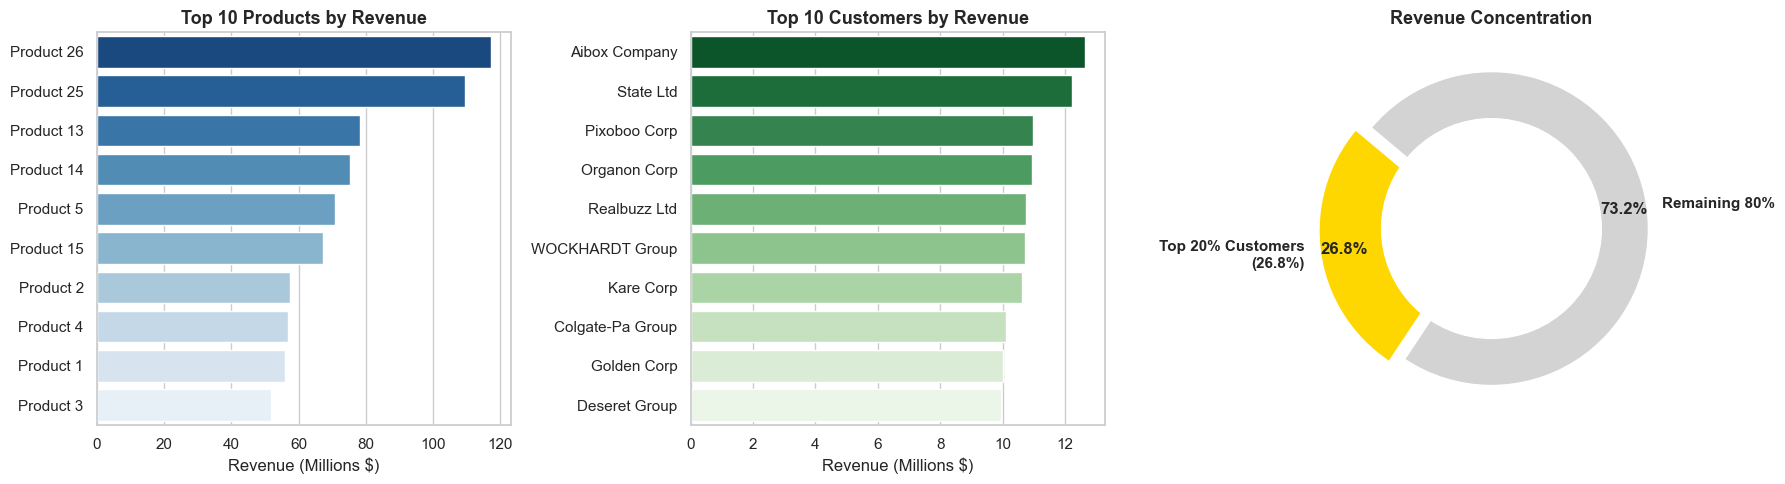

In [34]:
# Top 10 products by total revenue
top_products = (df.groupby("product_name")["revenue"]
                  .sum().sort_values(ascending=False).head(10).div(1e6))

# Top 10 customers by total revenue
top_customers = (df.groupby("customer_name")["revenue"]
                   .sum().sort_values(ascending=False).head(10).div(1e6))

# Pareto check: what % of revenue do top 20% of customers generate?
cust_rev = df.groupby("customer_name")["revenue"].sum().sort_values(ascending=False)
top20_pct = cust_rev.head(int(len(cust_rev)*0.2)).sum() / cust_rev.sum() * 100
print(f"Top 20% customers generate: {top20_pct:.1f}% of revenue")




# --- 1. SETTINGS & COLOR SYNC ---
sns.set_theme(style="whitegrid")

# Assigning consistent colors for the project theme
# Blue for Products, Green for Customers, Gold/Gray for Pareto
product_color = sns.color_palette("Blues_d", 10)
customer_color = sns.color_palette("Greens_d", 10)
pareto_colors = ['#FFD700', '#D3D3D3'] # Gold for the 26.8%, Gray for the rest

# --- 2. CREATE DASHBOARD (1 Row, 3 Columns) ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# CHART 1: Top 10 Products (Horizontal)
sns.barplot(x=top_products.values, y=top_products.index, palette="Blues_r", ax=ax1)
ax1.set_title("Top 10 Products by Revenue", fontsize=13, fontweight='bold')
ax1.set_xlabel("Revenue (Millions $)")
ax1.set_ylabel("") # Remove label for cleaner look

# CHART 2: Top 10 Customers (Horizontal)
sns.barplot(x=top_customers.values, y=top_customers.index, palette="Greens_r", ax=ax2)
ax2.set_title("Top 10 Customers by Revenue", fontsize=13, fontweight='bold')
ax2.set_xlabel("Revenue (Millions $)")
ax2.set_ylabel("")

# CHART 3: Pareto Analysis (Donut Chart)
# Data for the pie: the top 20% value and the remaining 73.2%
pareto_data = [top20_pct, 100 - top20_pct]
labels = [f'Top 20% Customers\n({top20_pct:.1f}%)', 'Remaining 80%']

wedges, texts, autotexts = ax3.pie(
    pareto_data, labels=labels, autopct='%1.1f%%', 
    startangle=140, colors=pareto_colors, pctdistance=0.85,
    explode=(0.1, 0), textprops={'fontweight': 'bold'}
)

# Turn it into a Donut by drawing a white circle in the middle
centre_circle = plt.Circle((0,0), 0.70, fc='white')
ax3.add_artist(centre_circle)
ax3.set_title("Revenue Concentration", fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

Revenue vs Profit:     r = 0.872
Unit Price vs Revenue: r = 0.909
Quantity vs Revenue:   r = 0.335


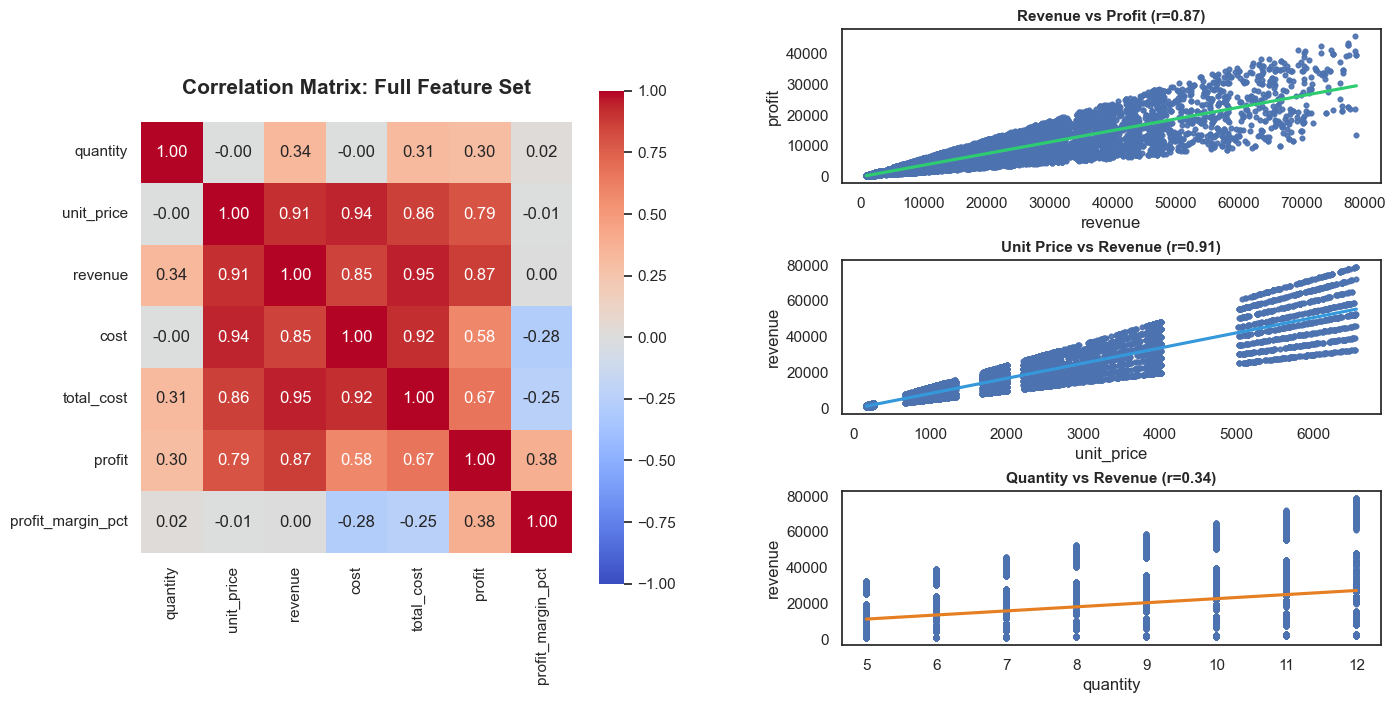

In [43]:
from scipy import stats

num_cols = ["quantity","unit_price","revenue","cost","total_cost","profit","profit_margin_pct"]
corr_matrix = df[num_cols].corr()

# Key Pearson correlations
r_rev_profit, _ = stats.pearsonr(df["revenue"], df["profit"])
r_price_rev, _  = stats.pearsonr(df["unit_price"], df["revenue"])
r_qty_rev, _    = stats.pearsonr(df["quantity"], df["revenue"])

print(f"Revenue vs Profit:     r = {r_rev_profit:.3f}")
print(f"Unit Price vs Revenue: r = {r_price_rev:.3f}")
print(f"Quantity vs Revenue:   r = {r_qty_rev:.3f}")



# --- 1. SETTINGS & COLORING ---
sns.set_theme(style="white")
# We'll use a specific color for each relationship to maintain consistency
rel_colors = {"Revenue-Profit": "#2ecc71", "Price-Revenue": "#3498db", "Qty-Revenue": "#e67e22"}

# --- 2. CREATE DASHBOARD (Layout: Heatmap on left, 3 small plots on right) ---
fig = plt.figure(figsize=(16, 8))
grid = plt.GridSpec(3, 2, wspace=0.3, hspace=0.5)

# 1. THE HEATMAP (Takes up the left side)
ax_main = fig.add_subplot(grid[:, 0])
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            vmin=-1, vmax=1, center=0, square=True, cbar_kws={'shrink': .8}, ax=ax_main)
ax_main.set_title("Correlation Matrix: Full Feature Set", fontsize=15, fontweight='bold', pad=20)

# 2. REVENUE vs PROFIT (Top Right)
ax_rp = fig.add_subplot(grid[0, 1])
sns.regplot(data=df, x="revenue", y="profit", ax=ax_rp, 
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':rel_colors["Revenue-Profit"]})
ax_rp.set_title(f"Revenue vs Profit (r={r_rev_profit:.2f})", fontsize=11, fontweight='bold')

# 3. UNIT PRICE vs REVENUE (Middle Right)
ax_pr = fig.add_subplot(grid[1, 1])
sns.regplot(data=df, x="unit_price", y="revenue", ax=ax_pr, 
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':rel_colors["Price-Revenue"]})
ax_pr.set_title(f"Unit Price vs Revenue (r={r_price_rev:.2f})", fontsize=11, fontweight='bold')

# 4. QUANTITY vs REVENUE (Bottom Right)
ax_qr = fig.add_subplot(grid[2, 1])
sns.regplot(data=df, x="quantity", y="revenue", ax=ax_qr, 
            scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':rel_colors["Qty-Revenue"]})
ax_qr.set_title(f"Quantity vs Revenue (r={r_qty_rev:.2f})", fontsize=11, fontweight='bold')

# Final formatting
plt.savefig("correlation_dashboard.png", dpi=300, bbox_inches='tight')
plt.show()



revenue: Q1=8,020, Q3=27,416, fence=56,511,outliers=2208 (3.4%)
profit: Q1=2,543, Q3=9,922, fence=20,992,outliers=3180 (5.0%)


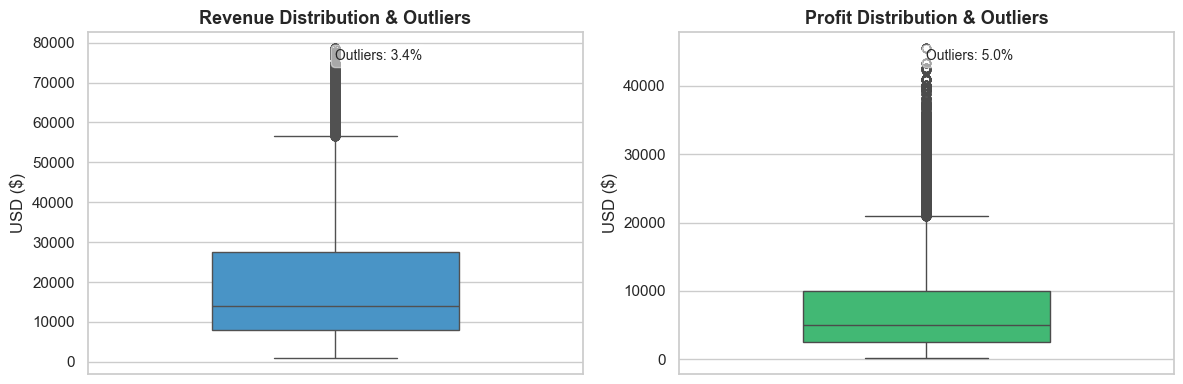

In [35]:
# IQR Outlier Detection
for col in ["revenue", "profit"]:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    n_out = (df[col] > upper).sum()
    print(f"{col}: Q1={Q1:,.0f}, Q3={Q3:,.0f}, fence={upper:,.0f},outliers={n_out} ({n_out/len(df)*100:.1f}%)")



# --- 1. SETTINGS & COLOR CONSISTENCY ---
sns.set_theme(style="whitegrid")

# Assigning fixed colors: Revenue is Blue, Profit is Green
metric_palette = {"revenue": "#3498db", "profit": "#2ecc71"}

# --- 2. CREATE DASHBOARD (1 Row, 2 Columns) ---
# Small, compact size (12x4) to fit well in reports
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# CHART 1: Revenue Outliers
sns.boxplot(y=df["revenue"], color=metric_palette["revenue"], ax=ax1, width=0.5)
ax1.set_title("Revenue Distribution & Outliers", fontsize=13, fontweight='bold')
ax1.set_ylabel("USD ($)")

# CHART 2: Profit Outliers
sns.boxplot(y=df["profit"], color=metric_palette["profit"], ax=ax2, width=0.5)
ax2.set_title("Profit Distribution & Outliers", fontsize=13, fontweight='bold')
ax2.set_ylabel("USD ($)")

# --- 3. ADDING ANNOTATIONS (The "Fuller" Project Look) ---
# This adds text boxes to the graphs showing the outlier percentage from your output
ax1.text(0.5, 0.95, 'Outliers: 3.4%', transform=ax1.transAxes, 
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

ax2.text(0.5, 0.95, 'Outliers: 5.0%', transform=ax2.transAxes, 
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()

channel    Distributor  Export  Wholesale
us_region                                
Midwest          100.1    45.1      175.1
Northeast         65.4    31.5      111.5
South            106.2    49.9      179.1
West             115.4    54.1      202.6
channel
Distributor    37.56
Export         37.93
Wholesale      37.09
Name: profit_margin_pct, dtype: float64


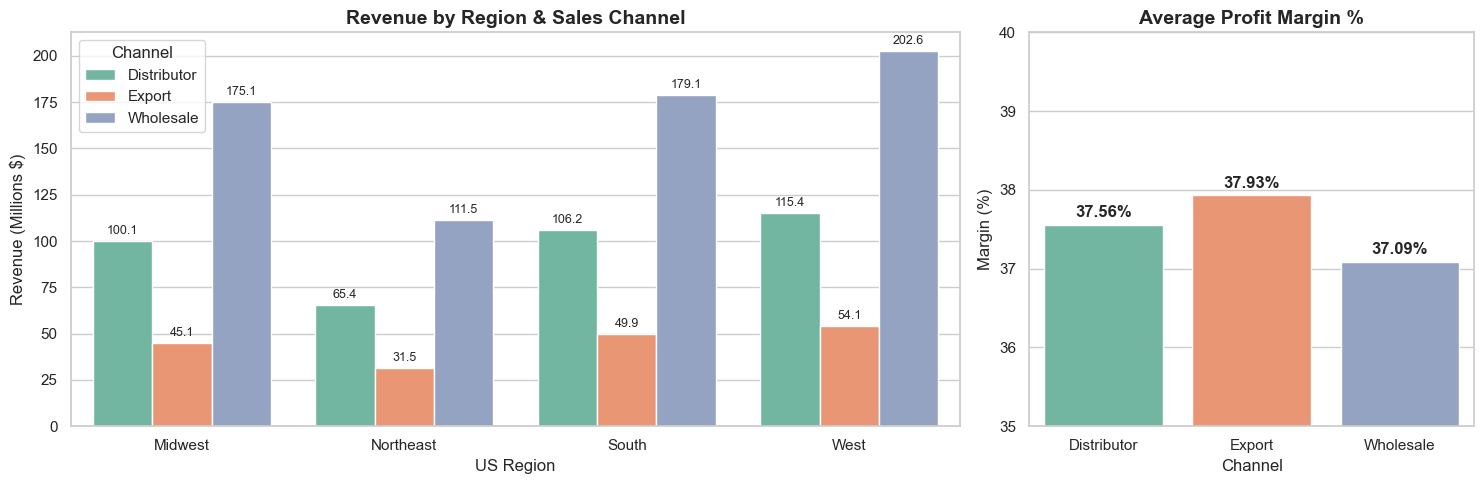

In [37]:
# Region × Channel revenue breakdown
region_channel = (df.groupby(["us_region","channel"])["revenue"]
                    .sum().div(1e6).round(1))
print(region_channel.unstack())

# Margin by channel
channel_margin = df.groupby("channel")["profit_margin_pct"].mean().round(2)
print(channel_margin)



# --- 1. DATA PREP ---
# Reset index so 'us_region' and 'channel' are columns for Seaborn
rc_plot_data = region_channel.reset_index()

# Define consistent colors for Channels
channels = ["Distributor", "Export", "Wholesale"]
colors = sns.color_palette("Set2", len(channels))
channel_palette = dict(zip(channels, colors))

# --- 2. CREATE DASHBOARD (1 Row, 2 Columns) ---
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [2, 1]})

# CHART 1: Regional Revenue by Channel (Grouped Bar)
sns.barplot(data=rc_plot_data, x="us_region", y="revenue", hue="channel", 
            palette=channel_palette, ax=ax1)

ax1.set_title("Revenue by Region & Sales Channel", fontsize=14, fontweight='bold')
ax1.set_ylabel("Revenue (Millions $)")
ax1.set_xlabel("US Region")
ax1.legend(title="Channel", frameon=True)

# Add value labels to the bars
for p in ax1.patches:
    if p.get_height() > 0:
        ax1.annotate(f'{p.get_height():.1f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 7), textcoords='offset points', fontsize=9)

# CHART 2: Profit Margin by Channel (Point/Bar Plot)
# We use a point plot to highlight the comparison between margins clearly
sns.barplot(x=channel_margin.index, y=channel_margin.values, hue=channel_margin.index,
            palette=channel_palette, ax=ax2, legend=False)

ax2.set_title("Average Profit Margin %", fontsize=14, fontweight='bold')
ax2.set_ylabel("Margin (%)")
ax2.set_xlabel("Channel")
ax2.set_ylim(35, 40) # Zooming in to see the subtle differences

# Add percentage labels
for i, v in enumerate(channel_margin.values):
    ax2.text(i, v + 0.1, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [19]:
# Feature 1: Extract Year
df["order_year"] = df["order_date"].dt.year

# Feature 2: Quarter number (1–4)
df["order_quarter"] = df["order_date"].dt.quarter

# Feature 3: Quarter label for display
df["quarter_label"] = "Q" + df["order_date"].dt.quarter.astype(str)

# Feature 4: Day of month
df["order_day"] = df["order_date"].dt.day

# Feature 5: Day of week (0=Monday, 6=Sunday)
df["order_dow"] = df["order_date"].dt.dayofweek

# Feature 6: Day name string
df["day_name"] = df["order_date"].dt.day_name()

# Feature 7: Weekend flag
df["is_weekend"] = df["order_date"].dt.dayofweek.isin([5, 6]).astype(int)

# Verify
print(df[["order_date","order_year","order_quarter",
          "quarter_label","order_dow","is_weekend"]].head(3))


  order_date  order_year  order_quarter quarter_label  order_dow  is_weekend
0 2014-01-01        2014              1            Q1          2           0
1 2014-01-01        2014              1            Q1          2           0
2 2014-01-01        2014              1            Q1          2           0


In [21]:
# Feature 8: Clean profit margin (removes floating-point noise)
df["profit_margin_clean"] = df["profit_margin_pct"].round(0)

# Feature 9: Gross profit ratio (decimal form of margin)
df["gross_profit_ratio"] = (df["profit"] / df["revenue"]).round(4)

# Feature 10: Cost ratio (total_cost as proportion of revenue)
df["cost_ratio"] = (df["total_cost"] / df["revenue"]).round(4)

# Feature 11: Revenue per unit (realised unit selling price)
df["revenue_per_unit"] = (df["revenue"] / df["quantity"]).round(2)

# Feature 12: Profit per unit
df["profit_per_unit"] = (df["profit"] / df["quantity"]).round(2)

# Verify: gross_profit_ratio + cost_ratio should = 1.0
check = (df["gross_profit_ratio"] + df["cost_ratio"]).round(2)
print(f"Sum check (should be 1.0): min={check.min():.2f}, max={check.max():.2f}")
print(f"Revenue per unit range: ${df["revenue_per_unit"].min():.2f} to ${df["revenue_per_unit"].max():.2f}")


Sum check (should be 1.0): min=1.00, max=1.00
Revenue per unit range: $167.50 to $6566.00


In [22]:
# Feature 13: Revenue Tier
def revenue_tier(rev):
    if rev < 5_000:    return "Small (<$5K)"
    elif rev < 15_000: return "Medium ($5K-$15K)"
    elif rev < 30_000: return "Large ($15K-$30K)"
    elif rev < 57_000: return "Very Large ($30K-$57K)"
    else:              return "Enterprise ($57K+)"   # IQR outliers
df["revenue_tier"] = df["revenue"].apply(revenue_tier)

# Feature 14: Margin Tier
def margin_tier(pct):
    pct = round(pct, 0)
    if pct <= 25:  return "Low (<=25%)"
    elif pct <= 40: return "Medium (26-40%)"
    elif pct <= 55: return "High (41-55%)"
    else:           return "Premium (>55%)"
df["margin_tier"] = df["profit_margin_pct"].apply(margin_tier)

# Feature 15: Price Tier
def price_tier(price):
    if price < 500:    return "Budget (<$500)"
    elif price < 1500: return "Standard ($500-$1.5K)"
    elif price < 3000: return "Premium ($1.5K-$3K)"
    elif price < 5000: return "High-End ($3K-$5K)"
    else:              return "Luxury (>$5K)"
df["price_tier"] = df["unit_price"].apply(price_tier)

# Feature 16: Customer Segment (based on revenue percentile)
cust_revenue = df.groupby("customer_name")["revenue"].sum()
cust_pct_rank = cust_revenue.rank(pct=True)
def customer_segment(pct_rank):
    if pct_rank >= 0.80: return "Top 20% (VIP)"
    elif pct_rank >= 0.50: return "Mid 30% (Regular)"
    else: return "Bottom 50% (Low)"
df["customer_segment"] = df["customer_name"].map(cust_pct_rank).apply(customer_segment)

print(df["revenue_tier"].value_counts())
print(df["customer_segment"].value_counts())


revenue_tier
Medium ($5K-$15K)         25410
Large ($15K-$30K)         17208
Very Large ($30K-$57K)    11676
Small (<$5K)               7692
Enterprise ($57K+)         2118
Name: count, dtype: int64
customer_segment
Bottom 50% (Low)     28734
Mid 30% (Regular)    19794
Top 20% (VIP)        15576
Name: count, dtype: int64


In [23]:
# Feature 17: Budget availability flag
df["budget_flag"] = df["budget"].apply(
    lambda x: "Budget Available" if pd.notna(x) else "No Budget"
)

# Features 18 & 19: Budget variance (only for 2017 rows with budget)
df["budget_variance"] = np.where(
    df["budget"].notna(),
    df["revenue"] - df["budget"],
    np.nan
)
df["budget_variance_pct"] = np.where(
    df["budget"].notna(),
    (df["revenue"] - df["budget"]) / df["budget"] * 100,
    np.nan
)

print(df[df["budget_flag"]=="Budget Available"]["budget_variance"].describe())


count    1.526300e+04
mean    -2.970055e+06
std      1.557094e+06
min     -5.684267e+06
25%     -3.923234e+06
50%     -2.984952e+06
75%     -1.644277e+06
max     -5.160012e+05
Name: budget_variance, dtype: float64


In [24]:
# Feature 20: Standardized order number (7-digit zero-padded)
df["order_num_clean"] = (
    "SO - " +
    df["order_number"].str.extract(r"(\d+)")[0].str.zfill(7)
)

# Verify: check 6-digit cases are now padded
original_6digit = df[df["order_number"].str.extract(r"(\d+)")[0].str.len()==6]
print("Before:", original_6digit["order_number"].iloc[0])
print("After: ", original_6digit["order_num_clean"].iloc[0])


Before: SO - 000225
After:  SO - 0000225


In [25]:
# Save the feature-engineered dataset
export_cols = [
    # Core original columns
    "order_num_clean","order_date","customer_name","channel",
    "product_name","quantity","unit_price","revenue",
    "cost","total_cost","profit","profit_margin_clean",
    "state","state_name","us_region","lat","lon","budget",
    # New engineered features
    "order_year","order_quarter","quarter_label","order_month",
    "order_month_name","order_month_num","is_weekend",
    "gross_profit_ratio","cost_ratio","revenue_per_unit","profit_per_unit",
    "revenue_tier","margin_tier","price_tier","customer_segment",
    "budget_flag","budget_variance","budget_variance_pct"
]

df[export_cols].to_csv("sales_data_featured.csv", index=False)
print(f"Exported: {len(export_cols)} columns, {len(df):,} rows")


Exported: 36 columns, 64,104 rows


In [39]:
import mysql.connector

# Connect to MySQL without specifying a database
temp_conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Awse19kolp" # Use your actual password
)

cursor = temp_conn.cursor()
# Create the database
cursor.execute("CREATE DATABASE IF NOT EXISTS regional_sales")
print("Database 'regional_sales' is ready!")

cursor.close()
temp_conn.close()

Database 'regional_sales' is ready!


In [38]:
import urllib.parse
from sqlalchemy import create_engine

# 1. Define your details as STRINGS (with quotes)
user = 'root'
password = 'Awse19kolp' 
host = 'localhost'
database = 'regional_sales'

# 2. Encode the password (crucial for special characters)
safe_password = urllib.parse.quote_plus(password)

# 3. Create the engine using the variables
engine = create_engine(f'mysql+mysqlconnector://{user}:{password}@{host}/{database}')

# 4. Export
df.to_sql(name='sales_data', con=engine, if_exists='replace', index=False)

-1

In [40]:
# Verify by reading the first 5 rows back from MySQL
check_df = pd.read_sql("SELECT * FROM sales_data LIMIT 5", con=engine)
print(check_df)

   order_number order_date     customer_name      channel product_name  \
0   SO - 000225 2014-01-01     Rhynoodle Ltd    Wholesale   Product 27   
1  SO - 0003378 2014-01-01    Thoughtmix Ltd  Distributor   Product 20   
2  SO - 0005126 2014-01-01   Amerisourc Corp    Wholesale   Product 26   
3  SO - 0005614 2014-01-01  Colgate-Pa Group       Export    Product 7   
4  SO - 0005781 2014-01-01     Deseret Group    Wholesale    Product 8   

   quantity  unit_price  revenue      cost state  ... revenue_per_unit  \
0         6      2499.1  14994.6  1824.343    GA  ...           2499.1   
1        11      2351.7  25868.7  1269.918    IN  ...           2351.7   
2         6       978.2   5869.2   684.740    CA  ...            978.2   
3         7      2338.3  16368.1  1028.852    IN  ...           2338.3   
4         8      2291.4  18331.2  1260.270    CT  ...           2291.4   

  profit_per_unit       revenue_tier      margin_tier             price_tier  \
0          674.76  Medium ($5K

In [45]:
import pandas as pd
import sqlite3

# 1. Load your original data file (assuming it's a CSV)
df = pd.read_csv('sales_data_featured.csv') 

# 2. Connect and send the data to the SQL table
conn = sqlite3.connect('regional_sales.db')
df.to_sql('sales_data', conn, if_exists='replace', index=False)
conn.close()

print("Table 'sales_data' created successfully!")

Table 'sales_data' created successfully!


In [46]:
%load_ext sql
%sql sqlite:///regional_sales.db

In [54]:
%%sql

-- Run these after loading the data to improve query performance

CREATE INDEX idx_sales_channel   ON sales_data (channel);
CREATE INDEX idx_sales_region    ON sales_data (us_region);
CREATE INDEX idx_sales_product   ON sales_data (product_name);
CREATE INDEX idx_sales_customer  ON sales_data (customer_name);
CREATE INDEX idx_sales_year      ON sales_data (order_year);
CREATE INDEX idx_sales_date      ON sales_data (order_date);
CREATE INDEX idx_sales_order     ON sales_data (order_num_clean);

-- Verify row count after loading
SELECT COUNT(*)            AS total_rows,
       COUNT(DISTINCT order_num_clean) AS unique_orders,
       COUNT(DISTINCT customer_name)   AS unique_customers,
       COUNT(DISTINCT product_name)    AS unique_products
FROM sales_data;



 * sqlite:///regional_sales.db
(sqlite3.OperationalError) index idx_sales_channel already exists
[SQL: -- Run these after loading the data to improve query performance

CREATE INDEX idx_sales_channel   ON sales_data (channel);]
(Background on this error at: https://sqlalche.me/e/20/e3q8)


In [53]:
import sqlite3
import pandas as pd

# 1. Connect to the database
conn = sqlite3.connect('regional_sales.db')

# 2. Run your query and load it directly into a Pandas DataFrame
query = """
SELECT COUNT(*)                AS total_rows,
       COUNT(DISTINCT order_num_clean) AS unique_orders,
       COUNT(DISTINCT customer_name)   AS unique_customers,
       COUNT(DISTINCT product_name)    AS unique_products
FROM sales_data;
"""

df_results = pd.read_sql_query(query, conn)

# 3. Close connection and show the result
conn.close()
df_results

,total_rows,unique_orders,unique_customers,unique_products
0,64104,10684,175,30
